# Fixed Dataset Analysis

Notebook for runs with `ABLATION_STUDY=False`, i.e. training on the fixed observed multimodal dataset without synthetic missingness.

The replicate definition depends on `RETRAIN_OUTER`:

- `RETRAIN_OUTER = False`: each retained `(seed, outer_fold, inner_model_k)` predictor is treated as one trained-model replicate.
- `RETRAIN_OUTER = True`: each `(seed, outer_fold)` refitted outer model is treated as one replicate.

The statistical workflow here is:

- rank methods by `mean AUC`
- test the global null of equal method distributions with a paired Friedman test over replicate AUCs
- summarise method-level significance through pairwise Wilcoxon signed-rank tests with FDR correction

A per-method omnibus p-value is not reported, because Friedman is a global test. Instead, each method gets counts of significant wins and losses from the pairwise Wilcoxon + FDR step.


In [1]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'analysis' else cwd

DATASET_NAME = 'mmCRC'
LABEL_NAME = 'OS_21_label'
RETRAIN_OUTER = False
RESULTS_MODE = 'fixed_dataset'

RESULTS_TAG = f'{DATASET_NAME}_{LABEL_NAME}' if str(LABEL_NAME).strip() else DATASET_NAME
RESULTS_ROOT = PROJECT_ROOT / 'results' / RESULTS_TAG / 'training_runs'
if not RESULTS_ROOT.exists():
    raise FileNotFoundError(f'Results root does not exist for dataset={DATASET_NAME!r}, label={LABEL_NAME!r}: {RESULTS_ROOT}')
if not RESULTS_ROOT.is_dir():
    raise NotADirectoryError(f'Expected a directory at: {RESULTS_ROOT}')

RETRAIN_TAG = f"retrain{str(bool(RETRAIN_OUTER)).lower()}"
OUTPUT_DIR = ((cwd / 'fixed_dataset_analysis_outputs') if cwd.name == 'analysis' else (cwd / 'analysis' / 'fixed_dataset_analysis_outputs')) / RESULTS_TAG / RETRAIN_TAG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT


PosixPath('/Users/marcalbesa/Desktop/TFM/git_exp/m3trics/results/mmCRC_OS_21_label/training_runs')

In [2]:
import sys
import importlib
import pandas as pd

ANALYSIS_DIR = cwd if cwd.name == 'analysis' else (cwd / 'analysis')
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import results_analysis as ra
ra = importlib.reload(ra)

HAVE_MPL = ra.HAVE_MPL
resolve_requested_model_names = ra.resolve_requested_model_names
load_all_test_predictions = ra.load_all_test_predictions
expand_inner_model_predictions = ra.expand_inner_model_predictions
aggregate_member_patient_predictions = ra.aggregate_member_patient_predictions
build_replicate_auc_table = ra.build_replicate_auc_table
build_level1_summary = ra.build_level1_summary
build_fixed_dataset_method_summary = ra.build_fixed_dataset_method_summary
build_fixed_dataset_method_significance_summary = ra.build_fixed_dataset_method_significance_summary
compute_fixed_dataset_global_friedman = ra.compute_fixed_dataset_global_friedman
compute_level2_pairwise_tests = ra.compute_level2_pairwise_tests
plot_fixed_dataset_auc_violins = ra.plot_fixed_dataset_auc_violins
plot_level3_pairwise_condition_matrices = ra.plot_level3_pairwise_condition_matrices


In [3]:
REQUESTED_MODEL_NAMES = resolve_requested_model_names(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    retrain_outer=RETRAIN_OUTER,
    results_mode=RESULTS_MODE,
)
if not REQUESTED_MODEL_NAMES:
    raise ValueError('No model folders were detected for the requested dataset / retrain flag / fixed-dataset mode.')

raw_predictions_df, missing_prediction_files = load_all_test_predictions(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    model_names=REQUESTED_MODEL_NAMES,
    retrain_outer=RETRAIN_OUTER,
    results_mode=RESULTS_MODE,
)
if raw_predictions_df.empty:
    raise ValueError('No fixed-dataset test_predictions.csv files were found.')

member_prediction_df = expand_inner_model_predictions(raw_predictions_df)
member_patient_df = aggregate_member_patient_predictions(member_prediction_df)
replicate_auc_df = build_replicate_auc_table(member_patient_df)
fixed_level1_df = build_level1_summary(replicate_auc_df=replicate_auc_df)
fixed_method_summary_df = build_fixed_dataset_method_summary(replicate_auc_df)
fixed_global_friedman_df = compute_fixed_dataset_global_friedman(replicate_auc_df)
fixed_pairwise_df = compute_level2_pairwise_tests(fixed_level1_df, replicate_auc_df)
fixed_method_table_df = build_fixed_dataset_method_significance_summary(fixed_method_summary_df, fixed_pairwise_df)

replicate_auc_path = OUTPUT_DIR / 'replicate_auc_table.csv'
fixed_level1_path = OUTPUT_DIR / 'fixed_dataset_method_condition_summary.csv'
fixed_method_summary_path = OUTPUT_DIR / 'fixed_dataset_method_summary.csv'
fixed_global_friedman_path = OUTPUT_DIR / 'fixed_dataset_global_friedman.csv'
fixed_pairwise_path = OUTPUT_DIR / 'fixed_dataset_pairwise_wilcoxon.csv'
fixed_method_table_path = OUTPUT_DIR / 'fixed_dataset_method_table.csv'
fixed_pairwise_significant_path = OUTPUT_DIR / 'fixed_dataset_pairwise_significant.csv'

replicate_auc_df.to_csv(replicate_auc_path, index=False)
fixed_level1_df.to_csv(fixed_level1_path, index=False)
fixed_method_summary_df.to_csv(fixed_method_summary_path, index=False)
fixed_global_friedman_df.to_csv(fixed_global_friedman_path, index=False)
fixed_pairwise_df.to_csv(fixed_pairwise_path, index=False)
fixed_method_table_df.to_csv(fixed_method_table_path, index=False)
fixed_pairwise_df.loc[fixed_pairwise_df['significant_fdr_0p05']].to_csv(fixed_pairwise_significant_path, index=False)

replicate_unit_label = 'seed x outer_fold' if bool(RETRAIN_OUTER) else 'seed x outer_fold x inner_model_k'
print(f'Replicate unit: {replicate_unit_label}')
print('Saved:', replicate_auc_path)
print('Saved:', fixed_level1_path)
print('Saved:', fixed_method_summary_path)
print('Saved:', fixed_global_friedman_path)
print('Saved:', fixed_pairwise_path)
print('Saved:', fixed_method_table_path)
print('Saved:', fixed_pairwise_significant_path)


Replicate unit: seed x outer_fold x inner_model_k
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/replicate_auc_table.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/fixed_dataset_method_condition_summary.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/fixed_dataset_method_summary.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/fixed_dataset_global_friedman.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/fixed_dataset_pairwise_wilcoxon.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/fixed_dataset_method_table.csv
Saved

## AUC Distribution Violin Plots

Replicate-level AUC distributions for each method, ordered by mean AUC. The white dot marks the median and the black diamond marks the mean.


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/figures/fixed_dataset_auc_violins.png


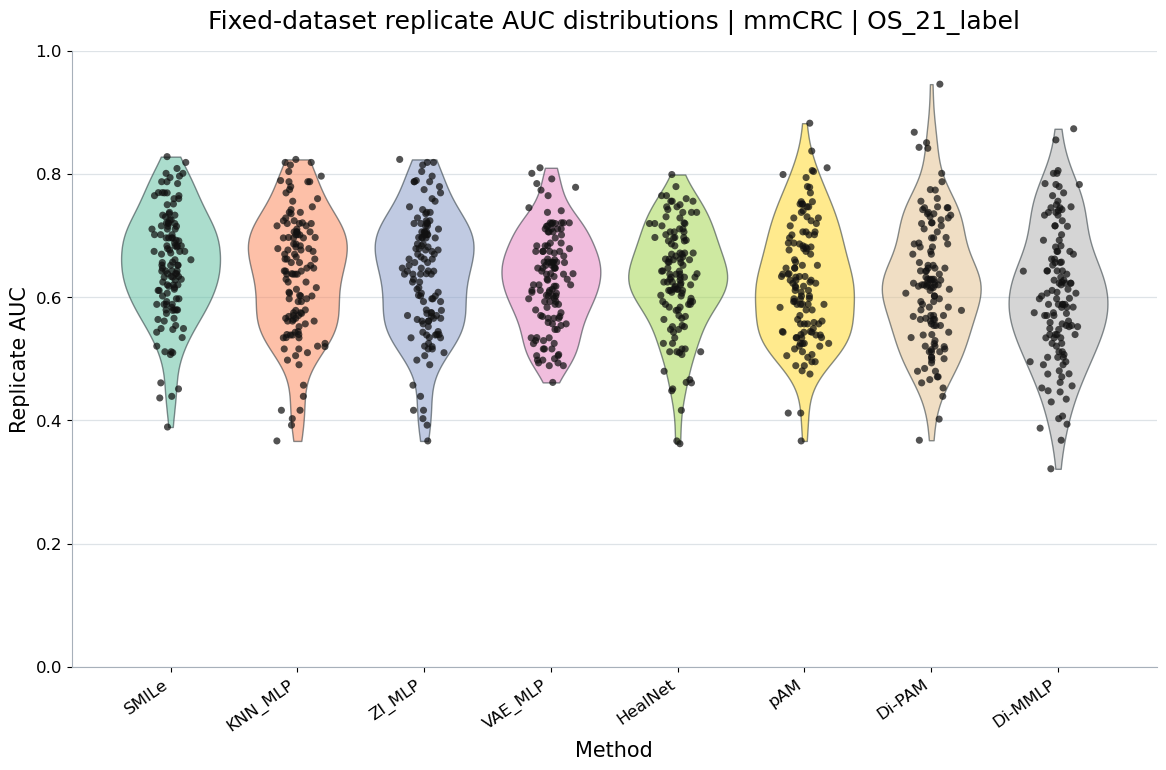

In [4]:
fixed_violin_title = f"Fixed-dataset replicate AUC distributions | {DATASET_NAME} | {LABEL_NAME}"
if HAVE_MPL:
    plot_fixed_dataset_auc_violins(
        replicate_auc_df=replicate_auc_df,
        method_summary_df=fixed_method_table_df,
        title=fixed_violin_title,
        figures_dir=FIGURES_DIR,
        file_name='fixed_dataset_auc_violins.png',
    )
else:
    print('Matplotlib is not available in this environment.')


## Method Ranking

Table ordered from best to worst by `mean AUC`.

- `95% CI` is the bootstrap half-width around the mean AUC.
- `Significant wins/losses` come from pairwise Wilcoxon signed-rank tests with FDR correction across all method pairs in this fixed dataset setting.
- The Friedman p-value below is the correct omnibus test for whether the paired replicate distributions differ globally across methods.


In [5]:
fixed_method_display_df = fixed_method_table_df[[
    'model_name',
    'mean_auc',
    'std_auc',
    'auc_ci95',
    'n_replicates',
    'significant_wins',
    'significant_losses',
]].rename(columns={
    'model_name': 'Model',
    'mean_auc': 'Mean AUC',
    'std_auc': 'Std AUC',
    'auc_ci95': '95% CI',
    'n_replicates': 'N replicates',
    'significant_wins': 'Significant wins',
    'significant_losses': 'Significant losses',
})
display(fixed_method_display_df)

print('Global Friedman test across paired replicate AUCs:')
display(fixed_global_friedman_df)


,Model,Mean AUC,Std AUC,95% CI,N replicates,Significant wins,Significant losses
0,SMILe,0.654561,0.088366,0.015446,125,5,0
1,KNN_MLP,0.636567,0.099889,0.017556,125,1,0
2,ZI_MLP,0.636567,0.099889,0.017997,125,1,0
3,VAE_MLP,0.628938,0.078799,0.014055,125,0,1
4,HealNet,0.628380,0.087866,0.015052,125,0,1
5,pAM,0.625116,0.096948,0.016910,125,0,1
6,Di-PAM,0.622552,0.103227,0.017059,125,0,1
7,Di-MMLP,0.604700,0.110679,0.019688,125,0,3


Global Friedman test across paired replicate AUCs:


,n_replicates,n_models,friedman_statistic,p_value,significant_p0_05
0,125,8,24.648145,0.000876,True


## Pairwise Wilcoxon Matrix

Single-condition pairwise Wilcoxon signed-rank matrix with FDR correction, ordered by `mean AUC`.

This is the fixed-dataset analogue of one heatmap cell from `MM_decay_analysis`.


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/fixed_dataset_analysis_outputs/mmCRC_OS_21_label/retrainfalse/figures/fixed_dataset_pairwise_wilcoxon_matrix.png


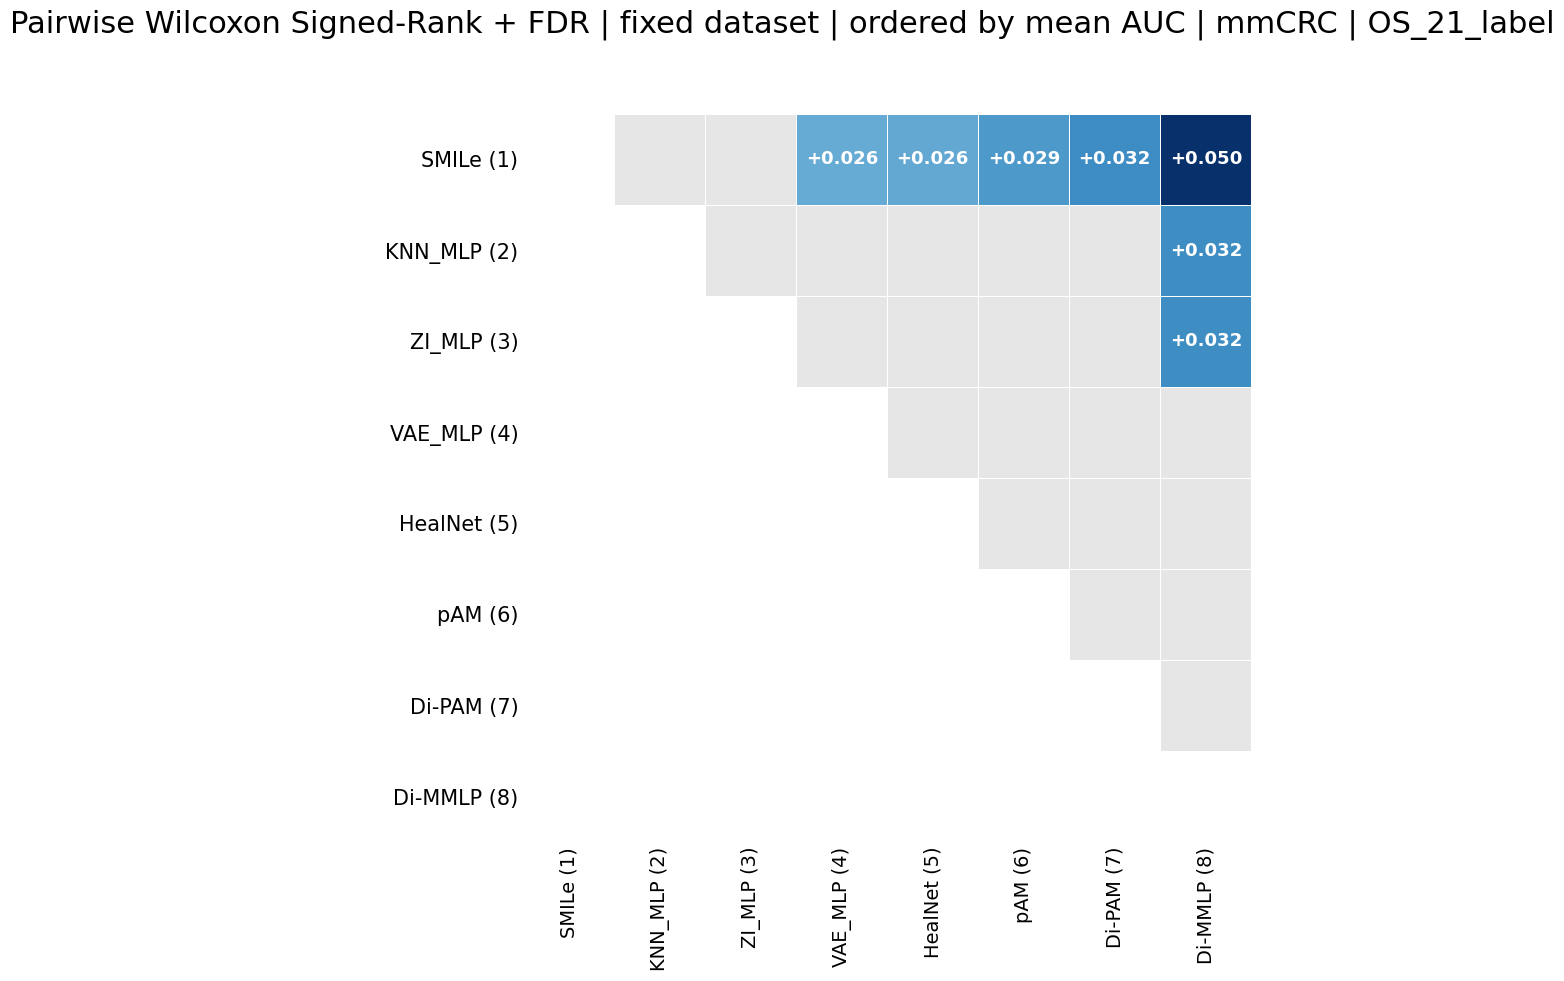

In [6]:
fixed_plot_title = f'Pairwise Wilcoxon Signed-Rank + FDR | fixed dataset | ordered by mean AUC | {DATASET_NAME} | {LABEL_NAME}'
if HAVE_MPL:
    plot_level3_pairwise_condition_matrices(
        level2_pairwise_df=fixed_pairwise_df,
        title=fixed_plot_title,
        figures_dir=FIGURES_DIR,
        file_name='fixed_dataset_pairwise_wilcoxon_matrix.png',
    )
else:
    print('Matplotlib is not available in this environment.')
